# Task 3, Part A: Images as Tensors
Before building a Vision Transformer, we need to understand how PyTorch handles image data. This notebook explores the MNIST and CIFAR-10 datasets, focusing on tensor shapes and pixel statistics.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Download MNIST
# transforms.ToTensor() converts PIL images to PyTorch tensors and scales pixels to [0, 1]
transform = transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.64MB/s]


### Image Shapes and Pixel Statistics
PyTorch uses the convention `(Channels, Height, Width)` for images. Let's verify this and look at the raw pixel values.

In [2]:
# Get the first image and label
img, label = mnist_train[0]

# 2. Print the shape of a single image
print(f"MNIST Image Shape: {img.shape}")
print("Note: PyTorch uses (Channels, Height, Width) format.\n")

# 4. Print pixel statistics: min, max, mean
print(f"Pixel Min: {img.min().item()}")
print(f"Pixel Max: {img.max().item()}")
print(f"Pixel Mean: {img.mean().item():.4f}")

MNIST Image Shape: torch.Size([1, 28, 28])
Note: PyTorch uses (Channels, Height, Width) format.

Pixel Min: 0.0
Pixel Max: 1.0
Pixel Mean: 0.1377


### Visualizing MNIST
To plot a grayscale image in Matplotlib, we need to remove the single channel dimension (e.g., changing `(1, 28, 28)` to `(28, 28)`) using `.squeeze()`.

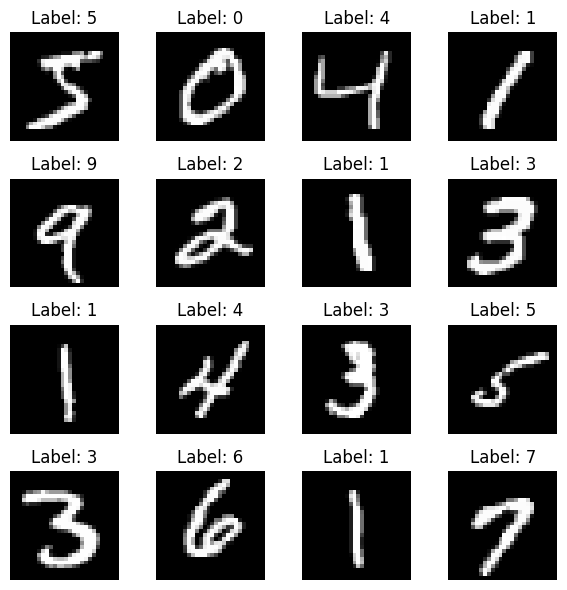

In [3]:
# 3. Visualize the first 16 images
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img, label = mnist_train[i]
    # Squeeze removes the channel dimension for display
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Moving to Color: CIFAR-10
CIFAR-10 contains RGB images, so the channel dimension will be 3. Matplotlib expects RGB images to be in `(Height, Width, Channels)` format, so we will use `.permute(1, 2, 0)` to swap the axes for plotting.

100%|██████████| 170M/170M [00:42<00:00, 4.01MB/s]


CIFAR-10 Image Shape: torch.Size([3, 32, 32]) -> (Channels, Height, Width)



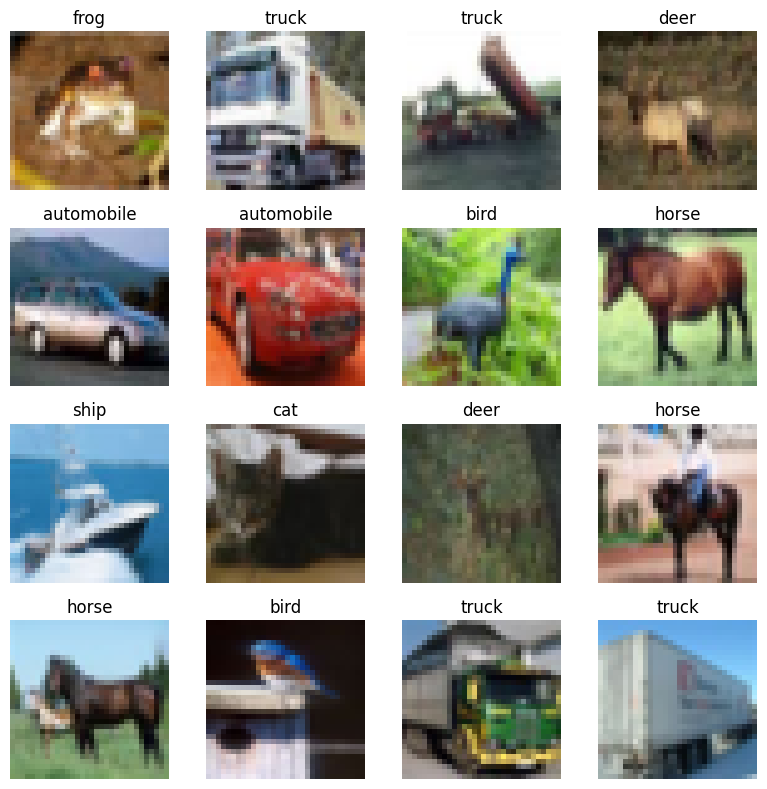

In [4]:
# 5. Download CIFAR-10
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_classes = cifar_train.classes

img_cifar, label_cifar = cifar_train[0]
print(f"CIFAR-10 Image Shape: {img_cifar.shape} -> (Channels, Height, Width)\n")

# Visualize 16 CIFAR-10 images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img, label = cifar_train[i]
    # PyTorch is (C, H, W). Matplotlib expects (H, W, C) for RGB images.
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(cifar_classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

### DataLoaders
DataLoaders handle batching our images so we can process multiple images simultaneously during training.

In [6]:
from torch.utils.data import DataLoader

# 6. Build a DataLoader with batch size 64
cifar_loader = DataLoader(cifar_train, batch_size=64, shuffle=True)

# Iterate one batch and print shapes
x_batch, y_batch = next(iter(cifar_loader))

print(f"Batch X (images) shape: {x_batch.shape} -> (Batch_Size, Channels, Height, Width)")
print(f"Batch Y (labels) shape: {y_batch.shape} -> (Batch_Size)")

Batch X (images) shape: torch.Size([64, 3, 32, 32]) -> (Batch_Size, Channels, Height, Width)
Batch Y (labels) shape: torch.Size([64]) -> (Batch_Size)
